<a href="https://colab.research.google.com/github/AbdulrahmanAhmed123/Text-Analysis-on-Great-Expections/blob/main/Great_Expectations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
textfile=open('great_expectations.txt','r',encoding='utf-8')
great_expect =textfile.read()
print(great_expect )


﻿The Project Gutenberg eBook of Great Expectations, by Charles Dickens

This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online at
www.gutenberg.org. If you are not located in the United States, you
will have to check the laws of the country where you are located before
using this eBook.

Title: Great Expectations

Author: Charles Dickens

Release Date: July, 1998 [eBook #1400]
[Most recently updated: April 27, 2020]

Language: English

Character set encoding: UTF-8

Produced by: An Anonymous Volunteer and David Widger

*** START OF THE PROJECT GUTENBERG EBOOK GREAT EXPECTATIONS ***

[Illustration]




Great Expectations

[1867 Edition]

by Charles Dickens


Contents

 Chapter I.
 Chapter II.
 Chapter III.
 Chapter IV.
 Chapter V.
 Chapter VI.
 Chapter VII.
 Chapt

In [49]:
%pip install nltk

In [50]:
%pip install gensim

In [51]:
%pip install wordcloud

In [52]:
import nltk
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from gensim.models import ldamodel
from gensim.models import coherencemodel
from gensim.corpora import Dictionary
from wordcloud import WordCloud

import pandas as pd
import numpy as np
import re
import random
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline

In [53]:
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [54]:
#Lowercase words for word cloud
word_cloud_text = great_expect.lower()
#Remove numbers and alphanumeric words we don't need for word cloud
word_cloud_text = re.sub("[^a-zA-Z0-9]", " ", word_cloud_text)

In [55]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

#Tokenize the data to split it into words
tokens = word_tokenize(word_cloud_text)
#Remove stopwords
tokens = (word for word in tokens if word not in stopwords.words('english'))
#Remove short words less than 3 letters in length
tokens = (word for word in tokens if len(word) >= 3)
#Add word cloud stopwords
stopwords_wc = set(stopwords.words("english"))


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [56]:
#Define gray_color_func function and mask variable for advanced word cloud
mask = np.array(Image.open("man_in_top_hat.jpeg"))
def gray_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return "hsl(0, 0%%, %d%%)" % random.randint(60, 100)

In [57]:


alphabets = "([A-Za-z])"
prefixes = "(Mr|St|Mrs|Ms|Dr)[.]"
suffixes = "(Inc|Ltd|Jr|Sr|Co)"
starters = r"(Mr|Mrs|Ms|Dr|Prof|Capt|Cpt|Lt|He\s|She\s|It\s|They\s|Their\s|Our\s|We\s|But\s|However\s|That\s|This\s|Wherever)"
acronyms = "([A-Z][.][A-Z][.](?:[A-Z][.])?)"
websites = r"[.](com|net|org|io|gov|edu|me)"
digits = "([0-9])"

text = " " + data + "  "
text = text.replace("\n", " ")

text = re.sub(prefixes, "\\1<prd>", text)
text = re.sub(websites, "<prd>\\1", text)
text = re.sub(digits + "[.]" + digits, "\\1<prd>\\2", text)

if "..." in text:
    text = text.replace("...", "<prd><prd><prd>")
if "Ph.D." in text:
    text = text.replace("Ph.D.", "Ph<prd>D<prd>")

text = re.sub(r"\s" + alphabets + "[.] ", " \\1<prd> ", text)
text = re.sub(acronyms + " " + starters, "\\1<stop> \\2", text)
text = re.sub(alphabets + "[.]" + alphabets + "[.]" + alphabets + "[.]", "\\1<prd>\\2<prd>\\3<prd>", text)
text = re.sub(alphabets + "[.]" + alphabets + "[.]", "\\1<prd>\\2<prd>", text)
text = re.sub(" " + suffixes + "[.] " + starters, " \\1<stop> \\2", text)
text = re.sub(" " + suffixes + "[.]", " \\1<prd>", text)
text = re.sub(" " + alphabets + "[.]", " \\1<prd>", text)

if "”" in text: text = text.replace(".”", "”.")
if "\"" in text: text = text.replace(".\"", "\".")
if "!" in text: text = text.replace("!\"", "\"!")
if "?" in text: text = text.replace("?\"", "\"?")

text = text.replace(".", ".<stop>")
text = text.replace("?", "?<stop>")
text = text.replace("!", "!<stop>")
text = text.replace("<prd>", ".")

sentences = text.split("<stop>")
sentences = [s.strip() for s in sentences]

sentences = [s for s in sentences if s]

sentences_df = pd.DataFrame(sentences, columns=['sentence'])

In [58]:
print(len(sentences_df))
(sentences_df.head(15))

10037


,sentence
0,﻿The Project Gutenberg eBook of Great Expectat...
1,"You may copy it, give it away or re-use it und..."
2,gutenberg.org.
3,"If you are not located in the United States, y..."
4,Title: Great Expectations Author: Charles Dic...
5,Chapter III.
6,Chapter IV.
7,Chapter V. Chapter VI.
8,Chapter VII.
9,Chapter VIII.


In [59]:
sentences_df.drop(sentences_df.index[:59],inplace=True)

sentences_df=sentences_df.reset_index()
sentences_df.head()

,index,sentence
0,59,[Illustration] Chapter I. My father’s fa...
1,60,"So, I called myself Pip, and came to be called..."
2,61,"I give Pirrip as my father’s family name, on t..."
3,62,"As I never saw my father or my mother, and nev..."
4,63,"The shape of the letters on my father’s, gave ..."


In [60]:
stopwords_wc=set(stopwords.words('english'))

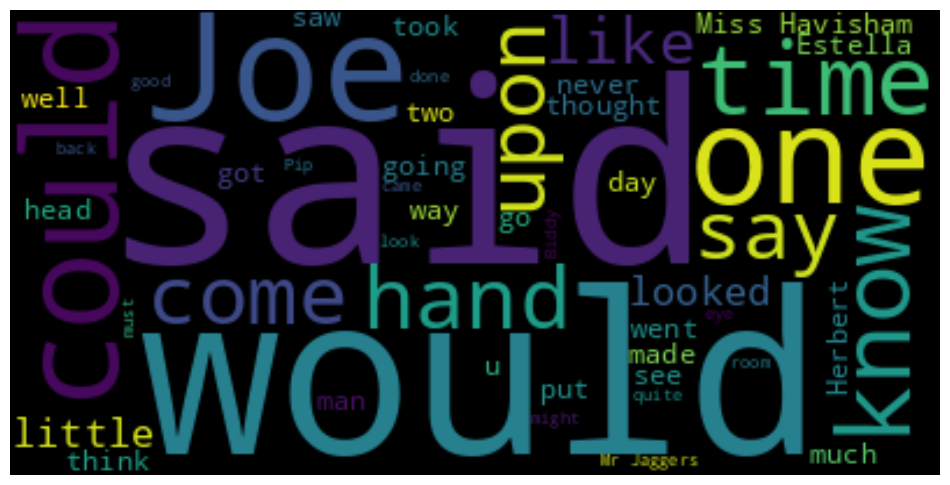

In [61]:

wordcloud=WordCloud(max_words=50,stopwords=stopwords_wc,random_state=1)
wordcloud=wordcloud.generate(great_expect)

plt.figure(figsize=(12,16))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.show()


In [62]:
mask=np.array(Image.open('man_in_top_hat.jpeg'))
def gray_color_func(word,font_size,position,orientation,randm_state=None,**kwargs):
  return "hsl(0,0%%,%d%%)" % random.randint(60,100)

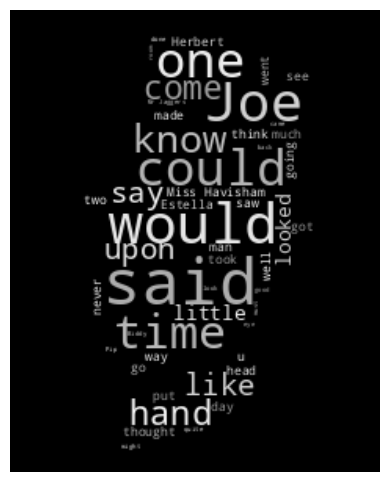

In [63]:
wordcloud=WordCloud(background_color='black',mask=mask,color_func=gray_color_func,max_words=50,stopwords=stopwords_wc,random_state=1)
wordcloud=wordcloud.generate(great_expect)
plt.figure(figsize=(8,6))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.show()


In [64]:
fdist=nltk.FreqDist(tokens)
fdist

FreqDist({'said': 1349, 'joe': 747, 'would': 599, 'one': 514, 'could': 484, 'know': 392, 'miss': 383, 'come': 375, 'time': 374, 'little': 371, ...})

In [65]:
fdist.most_common(50)

[('said', 1349),
 ('joe', 747),
 ('would', 599),
 ('one', 514),
 ('could', 484),
 ('know', 392),
 ('miss', 383),
 ('come', 375),
 ('time', 374),
 ('little', 371),
 ('upon', 368),
 ('pip', 341),
 ('like', 327),
 ('looked', 325),
 ('man', 321),
 ('havisham', 318),
 ('never', 315),
 ('old', 314),
 ('herbert', 313),
 ('much', 312),
 ('well', 304),
 ('say', 301),
 ('made', 300),
 ('went', 290),
 ('wemmick', 284),
 ('way', 278),
 ('see', 277),
 ('hand', 270),
 ('estella', 270),
 ('good', 257),
 ('two', 255),
 ('saw', 250),
 ('put', 246),
 ('back', 244),
 ('took', 243),
 ('jaggers', 242),
 ('think', 241),
 ('going', 241),
 ('got', 238),
 ('thought', 238),
 ('came', 235),
 ('head', 232),
 ('biddy', 231),
 ('might', 228),
 ('boy', 220),
 ('day', 219),
 ('night', 213),
 ('done', 212),
 ('dear', 209),
 ('must', 208)]

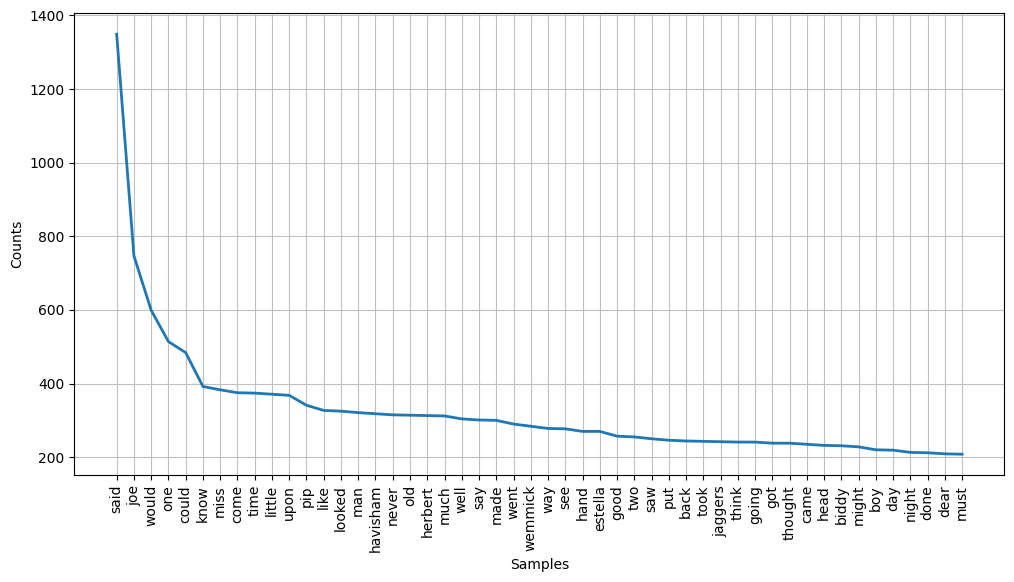

In [67]:
plt.figure(figsize=(12,6))
fdist.plot(50)
plt.show()

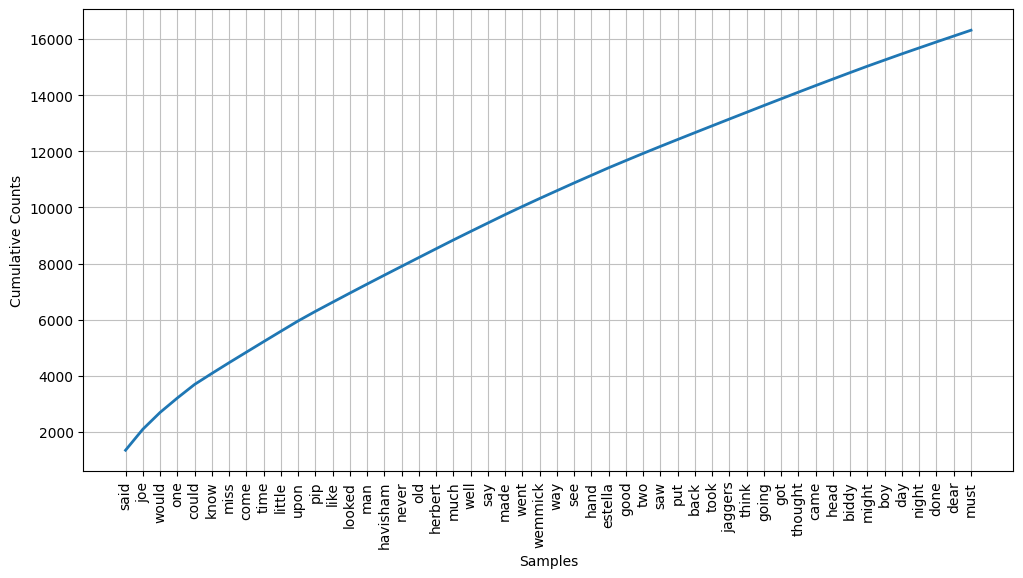

In [69]:
plt.figure(figsize=(12,6))
fdist.plot(50,cumulative=True)
plt.show()

In [70]:
analyzer=SentimentIntensityAnalyzer()

In [81]:
sentences_df.drop(columns=['index'], axis=1, inplace=True)

In [82]:
sentences_df['compound'] = [analyzer.polarity_scores(x)['compound'] for x in sentences_df['sentence']]
sentences_df['neg'] = [analyzer.polarity_scores(x)['neg'] for x in sentences_df['sentence']]
sentences_df['neu'] = [analyzer.polarity_scores(x)['neu'] for x in sentences_df['sentence']]
sentences_df['pos'] = [analyzer.polarity_scores(x)['pos'] for x in sentences_df['sentence']]



In [83]:
sentences_df.head(10)


,sentence,compound,neg,neu,pos
0,[Illustration] Chapter I. My father’s fa...,0.0000,0.000,1.000,0.000
1,"So, I called myself Pip, and came to be called...",0.0000,0.000,1.000,0.000
2,"I give Pirrip as my father’s family name, on t...",0.0772,0.000,0.942,0.058
3,"As I never saw my father or my mother, and nev...",0.3612,0.000,0.941,0.059
4,"The shape of the letters on my father’s, gave ...",-0.1531,0.088,0.846,0.065
5,From the character and turn of the inscription...,-0.2960,0.087,0.913,0.000
6,"To five little stone lozenges, each about a fo...",0.4404,0.047,0.883,0.070
7,"Ours was the marsh country, down by the river,...",0.0000,0.000,1.000,0.000
8,My first most vivid and broad impression of th...,0.5423,0.000,0.836,0.164
9,At such a time I found out for certain that th...,-0.9325,0.124,0.848,0.028


In [84]:
Positive_Sentence=sentences_df.loc[sentences_df['compound']>0]
Negative_Sentence=sentences_df.loc[sentences_df['compound']<0]
Natural_Sentence=sentences_df.loc[sentences_df['compound']==0]

print(sentences_df.shape)
print(len(Positive_Sentence))
print(len(Negative_Sentence))
print(len(Natural_Sentence))

(9978, 5)
3232
2452
4294


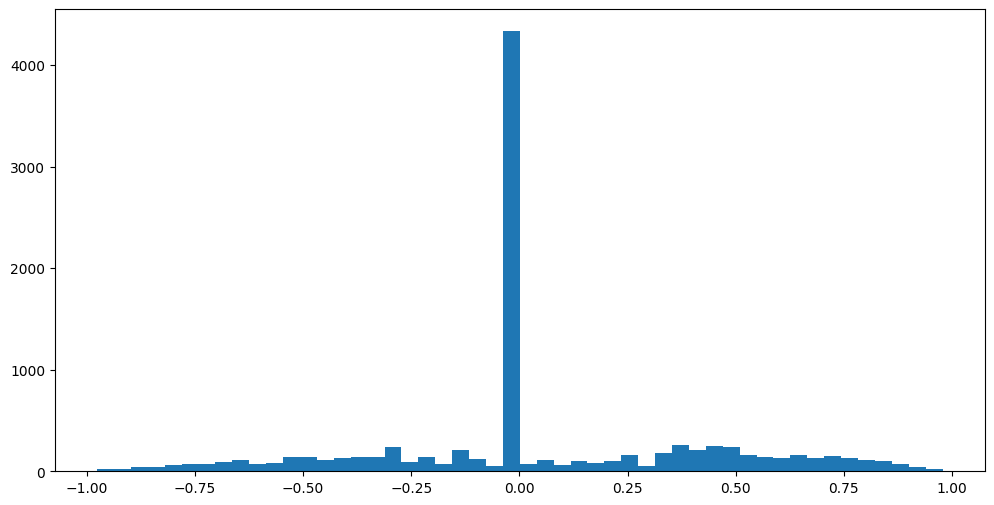

In [88]:
plt.figure(figsize=(12,6))
plt.hist(sentences_df['compound'],bins=50)
plt.show()

In [89]:
data=sentences_df['sentence'].values.tolist()
type(data)

list

In [90]:
#Text cleaning and tokenization using function
def text_processing(texts):
    #Remove numbers and alphanumerical words we don't need
    texts =  [re.sub("[^a-zA-Z]+", " ", str(text)) for text in texts]
    #Tokenize & lowercase each word
    texts = [[word for word in text.lower().split()] for text in texts]
    #Stem each word
    lmtzr = WordNetLemmatizer()
    texts = [[lmtzr.lemmatize(word) for word in text] for text in texts]
    #Remove stopwords
    stoplist = stopwords.words('english')
    texts = [[word for word in text if word not in stoplist] for text in texts]
    #Remove short words less than 3 letters in length
    texts = [[word for word in tokens if len(word) >= 3] for tokens in texts]
    return texts

In [91]:
data = text_processing(data)
dictionary=Dictionary(data)


In [92]:
len(dictionary)

9744

In [93]:
corpus=[dictionary.doc2bow(text) for text in data]
len(corpus)

9978

-5.006040620205682
-5.803605346564694
-5.5709199263261935
-6.849554588928772
-7.418697418152164
-8.160878493356782
-8.407041717836556


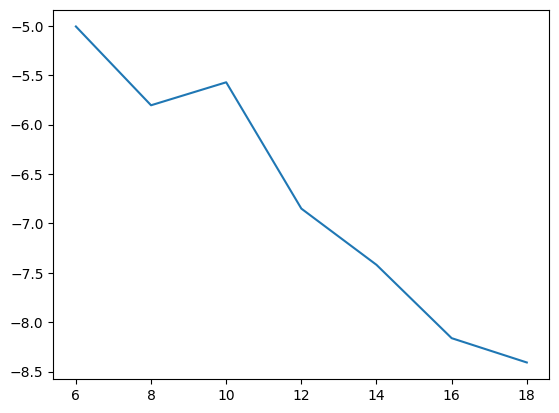

In [94]:
np.random.seed(1)
K_range=range(6,20,2)
scores=[]
for k in K_range:
  lda=ldamodel.LdaModel(corpus=corpus,id2word=dictionary,num_topics=k,passes=10)
  cm=coherencemodel.CoherenceModel(model=lda,corpus=corpus,dictionary=dictionary,coherence='u_mass')
  print(cm.get_coherence())
  scores.append(cm.get_coherence())
plt.figure()
plt.plot(K_range,scores)



In [95]:
lda=ldamodel.LdaModel(corpus=corpus,id2word=dictionary,num_topics=6,passes=10)

In [96]:
lda.show_topics()

[(0,
  '0.017*"would" + 0.016*"could" + 0.009*"old" + 0.009*"joe" + 0.008*"one" + 0.008*"time" + 0.008*"knew" + 0.007*"may" + 0.007*"never" + 0.007*"yes"'),
 (1,
  '0.015*"hand" + 0.011*"looked" + 0.010*"miss" + 0.009*"one" + 0.008*"saw" + 0.008*"havisham" + 0.008*"room" + 0.008*"went" + 0.008*"upon" + 0.008*"back"'),
 (2,
  '0.015*"well" + 0.011*"gutenberg" + 0.010*"work" + 0.010*"project" + 0.008*"could" + 0.008*"face" + 0.007*"like" + 0.007*"thought" + 0.006*"came" + 0.006*"time"'),
 (3,
  '0.017*"say" + 0.009*"asked" + 0.009*"nothing" + 0.008*"would" + 0.007*"way" + 0.007*"mean" + 0.006*"herbert" + 0.006*"pocket" + 0.006*"may" + 0.006*"whether"'),
 (4,
  '0.076*"said" + 0.028*"know" + 0.022*"pip" + 0.018*"dear" + 0.018*"wemmick" + 0.015*"joe" + 0.014*"boy" + 0.013*"jagger" + 0.012*"herbert" + 0.009*"tell"'),
 (5,
  '0.018*"come" + 0.013*"said" + 0.010*"good" + 0.010*"ever" + 0.009*"would" + 0.008*"little" + 0.008*"name" + 0.007*"child" + 0.007*"time" + 0.006*"night"')]